# ILUSTR 3 — Dobór stopnia wielomianu i co NAPRAWDĘ mówi twierdzenie Stone'a-Weierstrassa

Dwa pytania, jedna wspólna przyczyna (zbyt wysoki stopień wielomianu aproksymującego):

1. **Jak dobrać stopień $M$?** Za niski — model nie nadąża za kształtem danych
   (niedopasowanie). Za wysoki — wielomian zaczyna dopasowywać się do **szumu**, a nie do
   prawdziwej zależności (dokładnie ten sam mechanizm co efekt Rungego przy interpolacji,
   bo przy $M=N-1$ aproksymacja **staje się** interpolacją).
2. **Co naprawdę mówi twierdzenie Stone'a-Weierstrassa?** Że dla dowolnie małego błędu
   $\delta$ istnieje stopień $N$, przy którym błąd $|f(x)-P_N(x)|$ jest mniejszy niż
   $\delta$ **wszędzie** w $[a,b]$ — to twierdzenie o zbieżności **jednostajnej na całym
   przedziale**, NIE tylko o zerowym błędzie w węzłach danych. Pokażemy tu jawny
   kontrprzykład: wielomian może mieć zerowy błąd we wszystkich węzłach, a mimo to być
   fatalny pomiędzy nimi.

## 1. Krzywa błędu w funkcji stopnia: niedopasowanie → optimum → przeuczenie

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dane: prawdziwa zaleznosc kwadratowa + szum pomiarowy, N=15 punktow (jak w
# animacji StopienWielomianu z konspektu/planu prezentacji)
rng = np.random.default_rng(3)
N = 15
x = np.linspace(-3, 3, N)
y_true = 0.5 * x**2 - x + 2.0
szum = rng.normal(0, 1.0, size=N)
y = y_true + szum

stopnie = list(range(1, N))  # az do M=N-1 (interpolacja wszystkich N punktow)
bledy_dopasowania = []       # blad wzgledem ZASZUMIONYCH danych (to co model "widzi")
bledy_prawdy = []            # blad wzgledem PRAWDZIWEJ (nieznanej w praktyce) zaleznosci

x_gesto = np.linspace(x.min(), x.max(), 400)
y_true_gesto = 0.5 * x_gesto**2 - x_gesto + 2.0

for M in stopnie:
    p = np.polyfit(x, y, deg=M)
    # blad "widziany" przez model: RMS reszt wzgledem zaszumionych danych treningowych
    reszty = y - np.polyval(p, x)
    bledy_dopasowania.append(np.sqrt(np.mean(reszty**2)))
    # blad "prawdziwy": jak dobrze model odtwarza PRAWDZIWA (bezszumowa) zaleznosc,
    # oceniony na gestej siatce -- to jest to, czego w praktyce NIE znamy, ale co
    # naprawde nas interesuje
    bledy_prawdy.append(np.sqrt(np.mean((np.polyval(p, x_gesto) - y_true_gesto) ** 2)))

M_opt = stopnie[int(np.argmin(bledy_prawdy))]
assert bledy_dopasowania[-1] < 1e-6, "przy M=N-1 aproksymacja powinna stac sie interpolacja"
print(f"Prawdziwa zaleznosc jest kwadratowa -- oczekiwane minimum bledu wzgledem prawdy",
      f"blisko M=2, wyszlo M={M_opt} (zobacz wykres).")

Prawdziwa zaleznosc jest kwadratowa -- oczekiwane minimum bledu wzgledem prawdy blisko M=2, wyszlo M=2 (zobacz wykres).


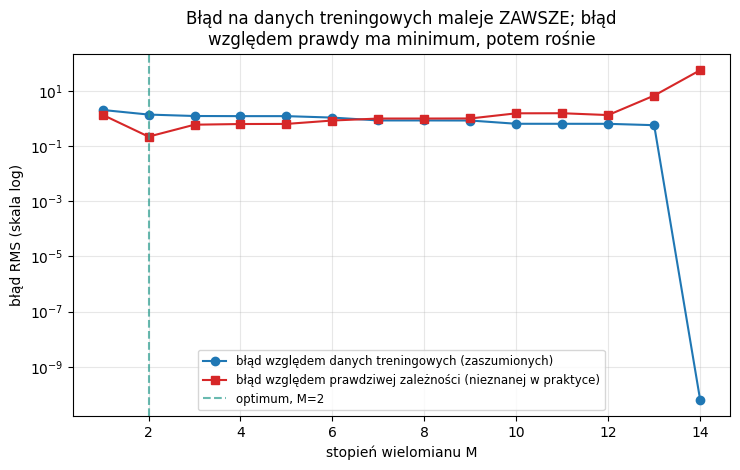

Niebieska krzywa spada MONOTONICZNIE do zera przy M=N-1 (aproksymacja STAJE SIE wtedy interpolacja), czerwona ma WYRAZNE MINIMUM, a potem rosnie -- to przeuczenie / efekt Rungego w przebraniu aproksymacji.


In [2]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.semilogy(stopnie, bledy_dopasowania, "o-", color="#1f77b4",
            label="błąd względem danych treningowych (zaszumionych)")
ax.semilogy(stopnie, bledy_prawdy, "s-", color="#d62728",
            label="błąd względem prawdziwej zależności (nieznanej w praktyce)")
ax.axvline(M_opt, color="#2a9d8f", ls="--", alpha=0.7, label=f"optimum, M={M_opt}")
ax.set_xlabel("stopień wielomianu M")
ax.set_ylabel("błąd RMS (skala log)")
ax.set_title("Błąd na danych treningowych maleje ZAWSZE; błąd\nwzględem prawdy ma minimum, potem rośnie")
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("Niebieska krzywa spada MONOTONICZNIE do zera przy M=N-1",
      "(aproksymacja STAJE SIE wtedy interpolacja), czerwona ma WYRAZNE MINIMUM, a",
      "potem rosnie -- to przeuczenie / efekt Rungego w przebraniu aproksymacji.")

## 2. Kontrprzykład: zerowy błąd w węzłach ≠ mały błąd wszędzie

Weźmy skrajny przypadek $M=N-1$ (wielomian interpolujący wszystkie punkty, więc błąd
**w węzłach jest dokładnie zero**) i porównajmy go z niskim, dobrze dobranym stopniem
($M=2$, zgodnym z prawdziwą zależnością) **pomiędzy** węzłami — najpierw dla WSZYSTKICH
stopni naraz, na jednym wykresie.

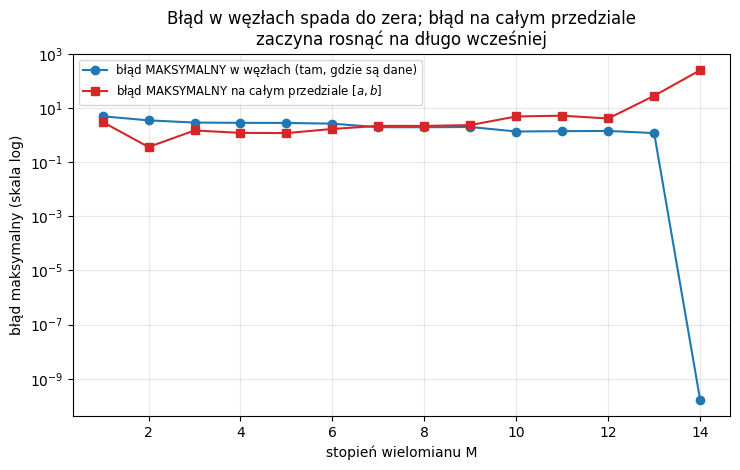

Niebieska krzywa (blad w wezlach) spada MONOTONICZNIE do zera, czerwona (blad na calym przedziale) ma minimum i potem eksploduje. To wlasnie obala bledna interpretacje: 'zero bledu w wezlach' NIE oznacza 'maly blad wszedzie'.


In [3]:
# Dla kazdego stopnia M osobno: jaki jest blad MAKSYMALNY W WEZLACH (tam, gdzie mamy
# dane) kontra blad MAKSYMALNY NA CALYM PRZEDZIALE (wzgledem prawdziwej zaleznosci)?
bledy_w_wezlach = []
bledy_wszedzie = []
for M in stopnie:
    pM = np.polyfit(x, y, deg=M)
    bledy_w_wezlach.append(np.max(np.abs(y - np.polyval(pM, x))))
    bledy_wszedzie.append(np.max(np.abs(np.polyval(pM, x_gesto) - y_true_gesto)))

assert bledy_w_wezlach[-1] < 1e-6  # M=N-1: interpolacja, zero bledu W WEZLACH z definicji
assert bledy_wszedzie[-1] > 10 * min(bledy_wszedzie), \
    "blad na calym przedziale przy najwyzszym M powinien byc duzo gorszy niz optimum"

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.semilogy(stopnie, bledy_w_wezlach, "o-", color="#1f77b4",
            label="błąd MAKSYMALNY w węzłach (tam, gdzie są dane)")
ax.semilogy(stopnie, bledy_wszedzie, "s-", color="#d62728",
            label="błąd MAKSYMALNY na całym przedziale $[a,b]$")
ax.set_xlabel("stopień wielomianu M"); ax.set_ylabel("błąd maksymalny (skala log)")
ax.set_title("Błąd w węzłach spada do zera; błąd na całym przedziale\nzaczyna rosnąć na długo wcześniej")
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("Niebieska krzywa (blad w wezlach) spada MONOTONICZNIE do zera,",
      "czerwona (blad na calym przedziale) ma minimum i potem eksploduje. To wlasnie",
      "obala bledna interpretacje: 'zero bledu w wezlach' NIE oznacza 'maly blad wszedzie'.")

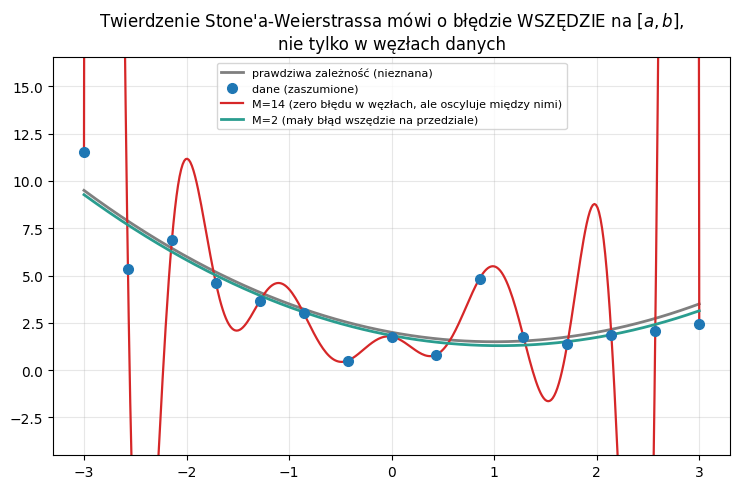

Czerwona krzywa (M wysokie) przechodzi PRZEZ kazdy niebieski punkt, ale miedzy nimi oscyluje daleko od szarej krzywej prawdy -- podczas gdy zielona (M niskie) trzyma sie szarej krzywej wszedzie.


In [4]:
# A teraz konkretnie dwa skrajne przypadki na wykresie funkcji -- zeby zobaczyc, jak
# TO WYGLADA, a nie tylko jak duzy jest blad w liczbach.
M_wysoki = N - 1   # interpolacja -- zero bledu W WEZLACH z definicji
M_niski = 2        # dobrze dobrany stopien (zgodny z prawdziwa zaleznoscia)
p_wysoki = np.polyfit(x, y, deg=M_wysoki)
p_niski = np.polyfit(x, y, deg=M_niski)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x_gesto, y_true_gesto, color="#7f7f7f", lw=2, label="prawdziwa zależność (nieznana)")
ax.plot(x, y, "o", ms=7, color="#1f77b4", zorder=5, label="dane (zaszumione)")
ax.plot(x_gesto, np.polyval(p_wysoki, x_gesto), color="#d62728", lw=1.6,
        label=f"M={M_wysoki} (zero błędu w węzłach, ale oscyluje między nimi)")
ax.plot(x_gesto, np.polyval(p_niski, x_gesto), color="#2a9d8f", lw=2,
        label=f"M={M_niski} (mały błąd wszędzie na przedziale)")
ax.set_ylim(min(y.min(), y_true_gesto.min()) - 5, max(y.max(), y_true_gesto.max()) + 5)
ax.set_title("Twierdzenie Stone'a-Weierstrassa mówi o błędzie WSZĘDZIE na $[a,b]$,\nnie tylko w węzłach danych")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
print("Czerwona krzywa (M wysokie) przechodzi PRZEZ kazdy",
      "niebieski punkt, ale miedzy nimi oscyluje daleko od szarej krzywej prawdy --",
      "podczas gdy zielona (M niskie) trzyma sie szarej krzywej wszedzie.")

## Najważniejsze wnioski

- Błąd liczony na danych treningowych maleje **zawsze** wraz ze wzrostem stopnia
  wielomianu (aż do zera przy $M=N-1$, gdzie aproksymacja staje się interpolacją) — to
  **nie jest** dobry sygnał do wyboru stopnia, bo przy wysokim $M$ wielomian zaczyna
  dopasowywać się do szumu, a nie do prawdziwej zależności.
- Właściwy stopień to ten, który minimalizuje błąd względem **prawdziwej** (w praktyce
  nieznanej) zależności — w praktyce szacowany np. przez podział danych na
  treningowe/testowe albo kryteria typu AIC/BIC (poza zakresem tego kursu).
- Twierdzenie Stone'a-Weierstrassa mówi o błędzie **jednostajnym na całym przedziale
  $[a,b]$**, nie tylko w węzłach — zerowy błąd w węzłach (jak przy interpolacji) **nie
  gwarantuje** małego błędu pomiędzy nimi, co jawnie pokazuje wykres w sekcji 2.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.polyfit(x, y, deg)` | Dopasowanie wielomianu stopnia `deg` metodą najmniejszych kwadratów |
| `np.polyval(p, x)` | Wyliczenie wartości wielomianu o współczynnikach `p` w punktach `x` |
| `np.argmin(...)` | Indeks minimum tablicy — użyty do znalezienia optymalnego stopnia $M$ |

## ĆWICZENIE

1. Zmień poziom szumu (`rng.normal(0, 1.0, ...)` na np. `0.2` albo `3.0`) i sprawdź, jak
   przesuwa się minimum krzywej błędu względem prawdy — dla mniejszego szumu, czy
   wielomian wyższego stopnia zaczyna wypadać lepiej?
2. Zmień prawdziwą zależność na sześcienną (`y_true = 0.3*x**3 - x**2 + 2`) i sprawdź na
   wykresie z sekcji 1, czy optymalny stopień $M$ przesuwa się w stronę 3.
3. **Rozszerzenie**: na wykresie z sekcji 2 (błąd w węzłach kontra błąd na całym
   przedziale) zaznacz pionową linią stopień $M$, przy którym obie krzywe zaczynają się
   wyraźnie rozjeżdżać — czy to ten sam moment, w którym błąd względem prawdy z sekcji 1
   zaczyna rosnąć?